<a href="https://colab.research.google.com/github/olicrea/Alura-Store-Latam-Informe/blob/main/AluraStoreLatam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Informe de Recomendación Estratégica: Alura Store Latam

El presente informe tiene como objetivo asesorar al Sr. Juan en la selección de la unidad de negocio más adecuada para ser desincorporada de su cadena, con el fin de capitalizar un nuevo emprendimiento. Para este análisis, se evaluaron cuatro tiendas bajo las siguientes métricas:
- Los ingresos totales de las tiendas.
- Las categorías de productos más y menos vendidas.
- Las calificaciones promedio de los clientes por tienda.
-Los productos más y menos vendidos.
- El coste de envío promedio para cada tienda.
- El desempeño geográfico

## Importación de datos



In [1]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


## Exploración de conjunto de datos


**Objetivo:** Comprender la estructura y contenido del conjunto de datos, con el propósito de identificar patrones, inconsistencias y las columnas más relevantes para los análisis posteriores.

**Método:** Se diseñó una función de automatización para la exploración básica de cada fuente de datos.

Para optimizar el procesamiento, se consolidaron los cuatro DataFrames en un diccionario de Python, lo que permitió iterar sobre todas las tiendas de forma simultánea, garantizando la uniformidad en el análisis y evitando la repetición innecesaria de código.

In [2]:
tiendas = {
    "Tienda 1": tienda,
    "Tienda 2": tienda2,
    "Tienda 3": tienda3,
    "Tienda 4": tienda4
}
def resumen(diccionario):
  for nombre, df_tienda in diccionario.items():
    print("-" * 80)
    print(f"📍 {nombre}:")
    print("-" * 80)
    print(f"SHAPE: {df_tienda.shape}")
    print(f"COLUMNS: {df_tienda.columns}")
    print("\n")
  print("\nINFO Tienda 1:")
  tienda.info()
  print("\nDESCRIBE Tienda 1:")
  display(tienda.describe())
resumen(tiendas)


--------------------------------------------------------------------------------
📍 Tienda 1:
--------------------------------------------------------------------------------
SHAPE: (2359, 12)
COLUMNS: Index(['Producto', 'Categoría del Producto', 'Precio', 'Costo de envío',
       'Fecha de Compra', 'Vendedor', 'Lugar de Compra', 'Calificación',
       'Método de pago', 'Cantidad de cuotas', 'lat', 'lon'],
      dtype='object')


--------------------------------------------------------------------------------
📍 Tienda 2:
--------------------------------------------------------------------------------
SHAPE: (2359, 12)
COLUMNS: Index(['Producto', 'Categoría del Producto', 'Precio', 'Costo de envío',
       'Fecha de Compra', 'Vendedor', 'Lugar de Compra', 'Calificación',
       'Método de pago', 'Cantidad de cuotas', 'lat', 'lon'],
      dtype='object')


--------------------------------------------------------------------------------
📍 Tienda 3:
-----------------------------------------

,Precio,Costo de envío,Calificación,Cantidad de cuotas,lat,lon
count,2.359000e+03,2359.000000,2359.000000,2359.000000,2359.000000,2359.000000
mean,4.878679e+05,26018.609580,3.976685,2.943196,5.365283,-74.789417
std,6.146868e+05,32860.001783,1.415370,2.819897,2.287445,1.217827
min,7.600000e+03,0.000000,1.000000,1.000000,-4.215280,-77.281110
25%,5.575000e+04,3100.000000,3.000000,1.000000,4.609710,-75.563590
50%,2.353000e+05,12400.000000,5.000000,1.000000,4.609710,-74.199040
75%,6.781000e+05,36000.000000,5.000000,4.000000,6.251840,-74.081750
max,2.977000e+06,160800.000000,5.000000,24.000000,11.544440,-67.923900



### Hallazgos de la estructura:
- Se observó una estructura homogénea que abarca dimensiones temporales, geográficas y comerciales.
- Todas las tiendas comparten la misma estructura (filas y columnas).
- Cada fila representa una venta.
- El tamaño de la muestra y la información que recoge es suficiente para un análisis de rendimiento del negocio.
- No hay valores nulos.
- Columnas correctamente ordenadas y separadas por tipo de información.
- Los nombres de algunas columnas pueden optimizarse para facilitar su uso
  en el análisis.
- La columna Fecha de compra se encuentra en formato object y debería
  convertirse a datetime para permitir análisis temporales.
- Clasificación de variables: Hay columnas numéricas y columnas categóricas:
  - Numéricas: Precio, Costo de envío, Calificación, Cantidad de cuotas, lat y lon.
  - Categóricas: Producto, Categoría del producto, Fecha de compra, Vendedor, Lugar de Compra, Método de pago.

## Optimización y preparación de datos

- Se estandarizaron los nombres de las columnas para facilitar su uso durante el análisis.
- Se utilizaron nombres en minúsculas y con guiones bajos, siguiendo buenas prácticas.
- Los cambios se aplicaron directamente sobre los DataFrames de cada tienda.
- Se realizó validación de integridad financiera.

In [3]:
def nombres_columnas(diccionario):
    for nombre, df in diccionario.items():
      df.rename(columns={
          'Producto' : 'producto',
          'Categoría del Producto' : 'categoria_producto',
          'Precio' : 'precio',
          'Costo de envío' : 'costo_envio',
          'Fecha de Compra' : 'fecha_compra',
          'Vendedor' : 'vendedor',
          'Lugar de Compra' : 'lugar_compra',
          'Calificación' : 'calificacion',
          'Método de pago' : 'metodo_pago',
          'Cantidad de cuotas' : 'cantidad_cuotas',
          'lat' : 'latitud',
          'lon' : 'longitud'
          }, inplace=True)


In [4]:
nombres_columnas(tiendas)
tienda.head()

,producto,categoria_producto,precio,costo_envio,fecha_compra,vendedor,lugar_compra,calificacion,metodo_pago,cantidad_cuotas,latitud,longitud
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


### Validación de integridad financiera

- Se auditó la columna precio en todas las tiendas.
- Se confirmó la ausencia de ventas con precios iguales o menores a cero, asegurando que no existan registros inválidos que distorsionen el cálculo de los ingresos totales.

In [5]:
def precios_cero(diccionario):
    for nombre, df in diccionario.items():
        print(f"{nombre}:")
        print((f"Registros con precios inválidos: {(df['precio']<=0).sum()}"))
        print("-" * 40)

In [6]:
precios_cero(tiendas)

Tienda 1:
Registros con precios inválidos: 0
----------------------------------------
Tienda 2:
Registros con precios inválidos: 0
----------------------------------------
Tienda 3:
Registros con precios inválidos: 0
----------------------------------------
Tienda 4:
Registros con precios inválidos: 0
----------------------------------------


#1. Análisis de facturación



**Objetivo:** Determinar la salud financiera de la cadena mediante el cálculo de los ingresos totales y la evaluación de la participación de mercado de cada unidad de negocio.

In [7]:
def ingresos(diccionario):
  ingresos_por_tienda = {}
  for nombre, df in diccionario.items():
    total_tienda = df['precio'].sum()
    ingresos_por_tienda[nombre] = total_tienda
  total_global = sum(ingresos_por_tienda.values())
  return ingresos_por_tienda, total_global


In [8]:
ingresos_por_tienda, total_global = ingresos(tiendas)

In [9]:
resumen = pd.DataFrame({
    'Ingreso Total ($)': ingresos_por_tienda,
    'Participación (%)': (pd.Series(ingresos_por_tienda) / total_global * 100)
}).sort_values(by='Ingreso Total ($)', ascending=False)

resumen_formateado = resumen.style.format({
    'Ingreso Total ($)': '${:,.0f}',
    'Participación (%)': '{:.2f}%'
})


print("-" * 50)
print(f"VENTAS TOTALES CADENA: ${total_global:,.0f}")
print("-" * 50)
print('VENTAS POR TIENDA:')

resumen_formateado

--------------------------------------------------
VENTAS TOTALES CADENA: $4,403,619,200
--------------------------------------------------
VENTAS POR TIENDA:


,Ingreso Total ($),Participación (%)
Tienda 1,"$1,150,880,400",26.13%
Tienda 2,"$1,116,343,500",25.35%
Tienda 3,"$1,098,019,600",24.93%
Tienda 4,"$1,038,375,700",23.58%


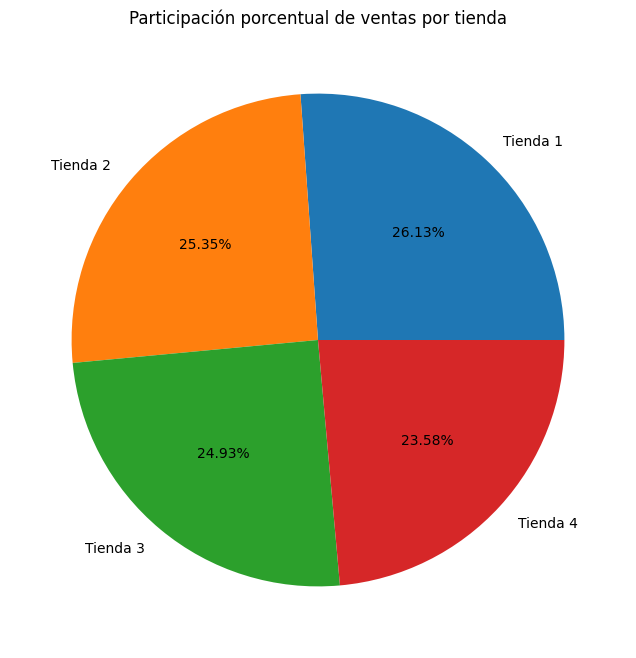

In [10]:
plt.figure(figsize=(8, 8))
resumen['Participación (%)'].plot(
    kind='pie',
    autopct='%1.2f%%'


)
plt.title("Participación porcentual de ventas por tienda")
plt.ylabel('') # Hide the default y-label as it's redundant for pie charts
plt.show()

## Hallazgos en el análisis de facturación:

- La facturación total consolidada de las cuatro tiendas asciende a $4,403,619,200.

- Liderazgo Moderado: La Tienda 1 se posiciona como el punto de venta con mayor recaudación, aunque la diferencia respecto a la segunda posición es menor al 1%.

- Homogeneidad de Mercado: La brecha máxima entre la tienda más exitosa (Tienda 1) y la de menor facturación (Tienda 4) es menor a 2 puntos porcentuales.

- Interpretación: Este equilibrio sugiere que la demanda y la capacidad operativa están distribuidas de forma equitativa, lo que minimiza el riesgo operativo al no depender de una sola sucursal "estrella".

# 2. Ventas por categoría

**Objetivo:** Identificar los segmentos de productos con mayor volumen de transacciones para comprender las preferencias del consumidor.

In [11]:
def ventas_por_categoria(diccionario):
  cantidad_ventas = {}
  for nombre, df in diccionario.items():
    cantidad_ventas[nombre] = df['categoria_producto'].value_counts().sort_values(ascending=False)
  return cantidad_ventas

In [12]:
cantidad_ventas = ventas_por_categoria(tiendas)
def tablas_ventas_tiendas():
  for nombre, tabla in cantidad_ventas.items():
    print("-" * 35)
    print(f'📍 {nombre}')
    print("-" * 35)
    display(tabla)
    print("\n")

In [13]:
tablas_ventas_tiendas()

-----------------------------------
📍 Tienda 1
-----------------------------------


,count
categoria_producto,
Muebles,465
Electrónicos,448
Juguetes,324
Electrodomésticos,312
Deportes y diversión,284
Instrumentos musicales,182
Libros,173
Artículos para el hogar,171




-----------------------------------
📍 Tienda 2
-----------------------------------


,count
categoria_producto,
Muebles,442
Electrónicos,422
Juguetes,313
Electrodomésticos,305
Deportes y diversión,275
Instrumentos musicales,224
Libros,197
Artículos para el hogar,181




-----------------------------------
📍 Tienda 3
-----------------------------------


,count
categoria_producto,
Muebles,499
Electrónicos,451
Juguetes,315
Electrodomésticos,278
Deportes y diversión,277
Libros,185
Instrumentos musicales,177
Artículos para el hogar,177




-----------------------------------
📍 Tienda 4
-----------------------------------


,count
categoria_producto,
Muebles,480
Electrónicos,451
Juguetes,338
Deportes y diversión,277
Electrodomésticos,254
Artículos para el hogar,201
Libros,187
Instrumentos musicales,170


In [14]:
df_unido = pd.concat(cantidad_ventas, axis=1).sort_values(by='Tienda 1', ascending=False).astype(int)
df_unido

,Tienda 1,Tienda 2,Tienda 3,Tienda 4
categoria_producto,,,,
Muebles,465,442,499,480
Electrónicos,448,422,451,451
Juguetes,324,313,315,338
Electrodomésticos,312,305,278,254
Deportes y diversión,284,275,277,277
Instrumentos musicales,182,224,177,170
Libros,173,197,185,187
Artículos para el hogar,171,181,177,201


<Figure size 640x480 with 0 Axes>

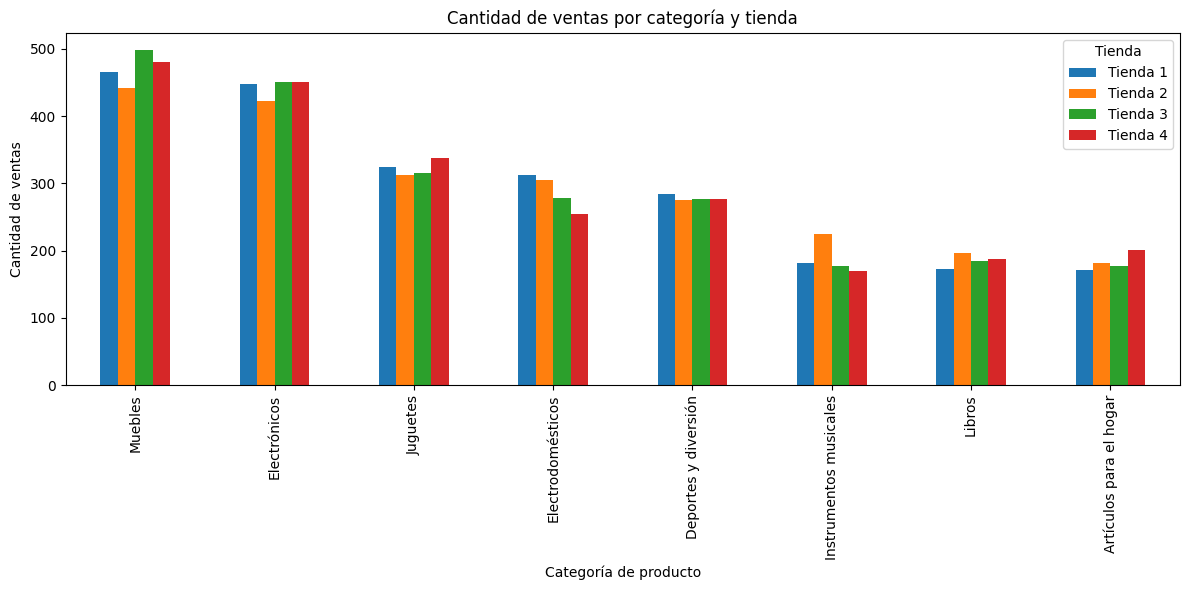

In [15]:
plt.figure()

df_unido.plot(
    kind='bar',
    figsize=(12,6)
)


plt.title("Cantidad de ventas por categoría y tienda")
plt.xlabel("Categoría de producto")
plt.ylabel("Cantidad de ventas")
plt.legend(title="Tienda")
plt.tight_layout()
plt.show()


### Hallazgos en ventas por categoría

- Categorías Líderes: Se observa una predominancia constante en categorías como Electrónicos y Muebles, las cuales mantienen volúmenes altos en las cuatro ubicaciones.

- Consistencia entre Tiendas: El gráfico de barras comparativo muestra que la distribución de ventas por categoría es prácticamente idéntica en todas las tiendas, lo que sugiere un perfil de cliente muy similar en toda la cadena.

- Especialización: Aunque las tiendas son muy parecidas, existen pequeñas variaciones en el orden de las categorías secundarias.

# 3. Calificación promedio de las tiendas


**Objetivo:** Evaluar la percepción de calidad y el nivel de satisfacción de los consumidores en cada unidad de negocio mediante el análisis de las reseñas.

In [16]:
def calificacion_por_tienda(diccionario):
  calificaciones = {}
  for nombre, df in diccionario.items():
    calificaciones[nombre] = df['calificacion'].mean()
  serie = pd.Series(calificaciones).sort_values(ascending=False)
  tabla_calificaciones = serie.reset_index()
  tabla_calificaciones.columns = ['Tienda', 'Calificación Promedio']
  return tabla_calificaciones

In [17]:
tabla_calificaciones = calificacion_por_tienda(tiendas).set_index("Tienda")
tabla_calificaciones.style.format({'Calificación Promedio': '{:.2f}'})

,Calificación Promedio
Tienda,
Tienda 3,4.05
Tienda 2,4.04
Tienda 4,4.00
Tienda 1,3.98


<Figure size 640x480 with 0 Axes>

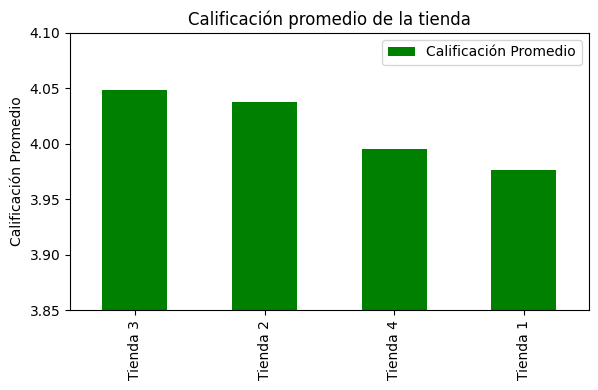

In [18]:
plt.figure()
tabla_calificaciones.plot(
    kind='bar',
    figsize=(6,4),
    color='green'
  )
plt.title("Calificación promedio de la tienda")
plt.ylabel("Calificación Promedio")
plt.xlabel('')
plt.tight_layout()
plt.ylim(3.85, 4.1)
plt.show()

## Hallazgos en calificación promedio de las tiendas

- Liderazgo en Satisfacción: La Tienda 3 y la Tienda 2 encabezan la lista con las calificaciones promedio más altas, 4.05 y 4.04 respectivamente.

- Consistencia del Servicio: Todas las tiendas mantienen un promedio superior a 3.9, lo que indica una experiencia de cliente positiva y estandarizada. La tienda 4 a pesar de ser la de menores ingresos, mantiene una calificación competitiva, sugiriendo que su bajo volumen no se debe a una mala atención.

- Rango de Variación: La diferencia entre la tienda mejor calificada y la de menor puntaje es de menos de 0.1 puntos, lo que sugiere que la calidad del producto y la atención no dependen de la ubicación geográfica.

**Nota sobre la Visualización:**
Para resaltar estas pequeñas diferencias, el análisis gráfico utiliza un eje Y ajustado (rango de 3.85 a 4.1), permitiendo identificar a las tiendas con mejor desempeño relativo, aunque todas se encuentran en un nivel de excelencia similar.

# 4. Productos más y menos vendidos

**Objetivo:** Identificar los productos con mayor y menor rotación en cada tienda para optimizar la gestión.

In [19]:
def productos_top_bottom(diccionario):
  for nombre, df in diccionario.items():
    cantidad_ventas_productos =df['producto'].value_counts()
    mas_vendido = cantidad_ventas_productos.sort_values(ascending=False).head(3)
    menos_vendido = cantidad_ventas_productos.sort_values(ascending=True).head(3)
    top_bottom = pd.concat([menos_vendido, mas_vendido])

    plt.figure()
    top_bottom.sort_values(ascending=True).plot(
        kind='barh',
        figsize=(5,4),
        color=['red', 'red', 'red', 'green', 'green', 'green']
    )

    plt.title(f'{nombre}')
    plt.ylabel('')
    plt.xlabel('Cantidad de ventas')
    plt.tight_layout()
    plt.xlim(10, 68)
    plt.show()

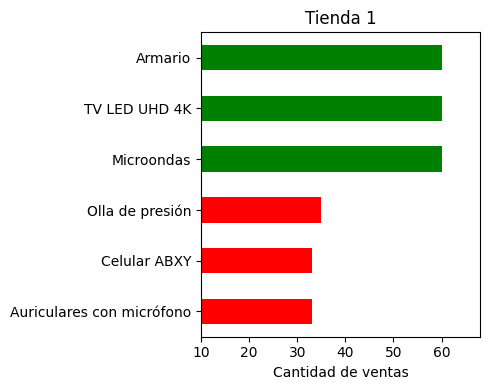

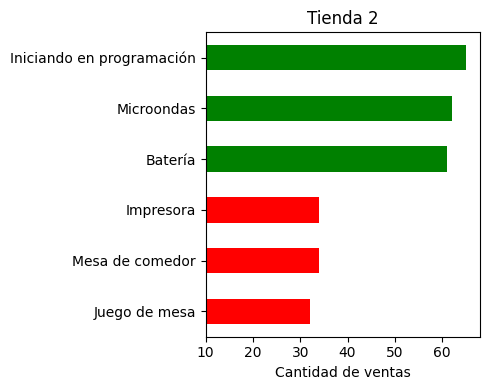

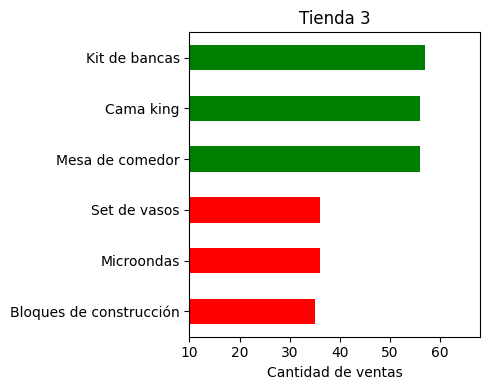

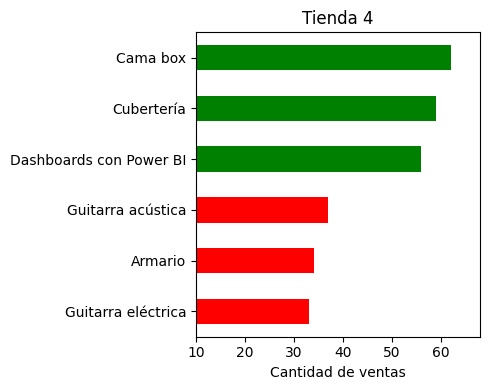

In [20]:
productos_top_bottom(tiendas)

## Hallazgos en productos más y menos vendidos

- En todas las tiendas, se identificaron productos con una demanda que supera las 60 unidades vendidas, lo que representa los artículos "estrella" de la cadena.

- La Tienda 2 muestra un liderazgo claro en ciertos artículos que alcanzan casi las 70 ventas, consolidando su posición como la sucursal de mayor volumen.

- Se detectaron productos con un rendimiento crítico, con ventas que caen por debajo de las 20 unidades en algunas sucursales.

- Existe una brecha significativa entre los productos líderes y los rezagados.

# 5. Envío promedio por tienda

**Objetivo:** Calcular el costo de envío promedio para cada tienda. y así comprender cuánto se gasta, en promedio, en el envío de cada tienda, sabiendo que el cliente paga el envío.

In [21]:
def costo_envio_promedio(diccionario):
  all_costos_promedio = {}
  for nombre, df in diccionario.items():
    costo_envio_promedio_tienda = df['costo_envio'].mean()
    all_costos_promedio[nombre] = costo_envio_promedio_tienda

  tabla = pd.DataFrame.from_dict(
      all_costos_promedio,
      orient='index',
      columns=['Costo promedio']
  )
  return tabla

In [22]:
tabla = costo_envio_promedio(tiendas)
tabla.style.format({'Costo promedio': '${:,.0f}'})

,Costo promedio
Tienda 1,"$26,019"
Tienda 2,"$25,216"
Tienda 3,"$24,806"
Tienda 4,"$23,459"


<Figure size 640x480 with 0 Axes>

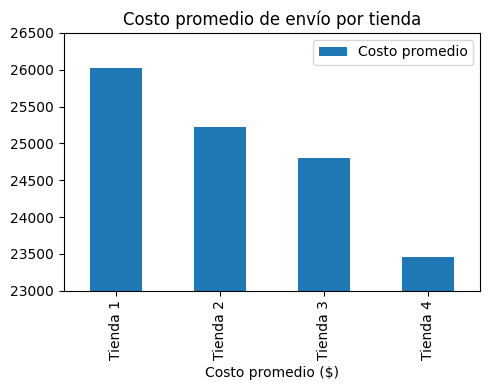

In [23]:
plt.figure()
tabla.sort_values(by='Costo promedio', ascending=False).plot(
    kind='bar',
    figsize=(5,4)
    )

plt.title('Costo promedio de envío por tienda')
plt.ylabel('')
plt.xlabel('Costo promedio ($)')
plt.tight_layout()
plt.ylim(23000, 26500)

plt.show()

## Hallazgos en envío promedio por tienda

- Promedio General: El costo de envío se mantiene en un costo similar por transacción.

- Tienda con Menor Costo: La Tienda 4 presenta el costo promedio de envío más bajo (cercano a los $23,000), lo que podría estar relacionado con una ubicación geográfica más favorable.

- Tienda con Mayor Costo: La Tienda 1, a pesar de ser la líder en facturación, también registra uno de los costos de envío más elevados (superando los $26,000).

- A diferencia de las calificaciones de los clientes, los costos de envío muestran una mayor dispersión visual en los gráficos.

# 6. Análisis del desempeño geográfico

**Objetivo:** explorar las coordenadas geográficas de los datos de ventas e identificar patrones relacionados con la ubicación de las compras.

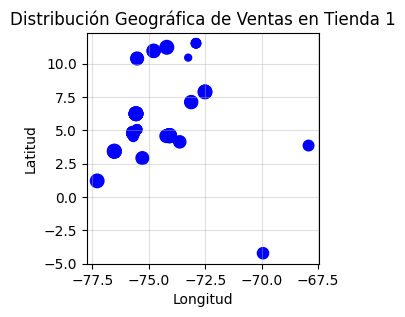

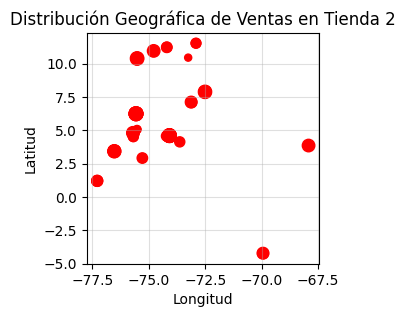

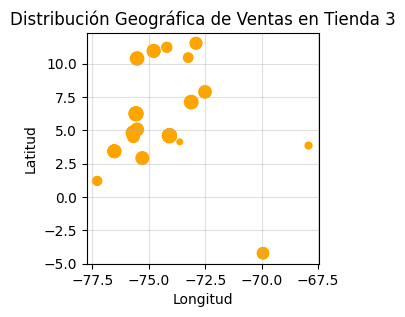

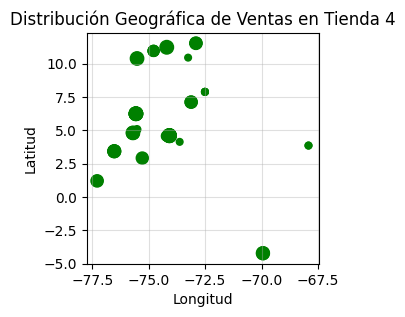

In [24]:
def mapa_ventas(diccionario):

  colores = {'Tienda 1': 'blue', 'Tienda 2': 'red', 'Tienda 3': 'orange', 'Tienda 4': 'green'}

  for nombre, df in diccionario.items():
    plt.figure(figsize=(3, 3))
    plt.scatter(
    df['longitud'],
    df['latitud'],
    s=df['precio'] / 30000,
    c=colores[nombre]
    )

    plt.title(f'Distribución Geográfica de Ventas en {nombre}')
    plt.xlabel('Longitud')
    plt.ylabel('Latitud')
    plt.grid(True, alpha=0.4)
    plt.show()

mapa_ventas(tiendas)

## Hallazgos de análisis del desempeño geográfico

- Los gráficos de dispersión generados muestran que el desempeño geográfico tiene un patrón muy similar en las 4 sucursales. Esto quiere decir que sea cual sea la elección final de la tienda a vender se podrán abarcar con eficiencia los mismos territorios sin afectar la cobertura de clientes existentes.

# Conclusión y Recomendación Final

Tras analizar los datos recolectados, la recomendación para el Sr. Juan es: **Vender la TIENDA 4.**

## Justificación

Es importante destacar que todas las sucursales de Alura Store presentan un rendimiento saludable, una satisfacción del cliente sólida (superior a 3.9) y una cobertura de territorio muy similar. No obstante, al hilar fino en los datos, la Tienda 4 es la que presenta el menor volumen de facturación y la menor participación de mercado, lo que la convierte en la opción con menor impacto negativo para el flujo de caja global de la cadena.

Por otro lado, a diferencia de las demás, la Tienda 4 ha logrado la mayor eficiencia en costos de envío. Esto permite entregar al comprador una unidad con procesos logísticos optimizados, lo que garantiza un valor de venta justo y atractivo en el mercado.

La desincorporación de esta sucursal no compromete la estabilidad financiera de Alura Store, ya que las Tiendas 1, 2 y 3 retienen más del 75% de los ingresos totales y mantienen los volúmenes de venta más altos en las categorías líderes como Electrónicos y Muebles.

**Conclusión:** La venta de la Tienda 4 representa la mejor oportunidad de negocio. Permite al Sr. Juan obtener el capital necesario para su nuevo proyecto, asegurando que el comprador reciba un producto atractivo y que Alura Store continúe su crecimiento con sus sedes más productivas.

